# Risk Scoring and Fleet Ranking

This notebook converts Remaining Useful Life (RUL) predictions into
operational aviation safety metrics.

While previous notebooks focused on predictive modeling, this stage
transforms model outputs into actionable maintenance insights that
can support airline safety and reliability operations.

## Objectives

- Load engine-level RUL predictions
- Convert predicted RUL into normalized risk scores
- Classify engines into safety risk levels (High / Medium / Low)
- Generate early warning alerts for high-risk engines
- Rank engines across the fleet by predicted failure risk

These outputs support predictive maintenance planning and fleet-level
safety monitoring in aviation environments.risk priority

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Test Sequences and Trained Models

In this step we load the prepared FD004 test sequences generated in
previous notebooks, along with the trained deep learning models.

These models will be used to generate Remaining Useful Life (RUL)
predictions for each engine, which will then be converted into
aviation safety risk indicators.

Loaded components:

• FD004 test sequences  
• Trained LSTM model  
• Trained GRU model  

These predictions form the foundation for fleet-level risk scoring
and maintenance prioritization.s.s.

In [2]:
from pathlib import Path

# Base project directory
BASE_DIR = Path(r"C:\Users\Kal\aircraft-engine-safety-risk-prediction")

# Data directory (processed datasets from previous notebooks)
DATA_DIR = BASE_DIR / "data" / "processed"

# Trained models directory
MODEL_DIR = BASE_DIR / "models"

# Output directory for risk analysis results
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Processed data:", DATA_DIR)
print("Models:", MODEL_DIR)
print("Outputs:", OUTPUT_DIR)

Base directory: C:\Users\Kal\aircraft-engine-safety-risk-prediction
Processed data: C:\Users\Kal\aircraft-engine-safety-risk-prediction\data\processed
Models: C:\Users\Kal\aircraft-engine-safety-risk-prediction\models
Outputs: C:\Users\Kal\aircraft-engine-safety-risk-prediction\outputs


## Load Engine-Level Test Arrays

Load the saved engine-level FD004 test arrays created in Notebook 02.
These represent the latest window per engine and are used for fleet-level risk analysis.

In [3]:
import numpy as np

X_test_last = np.load(DATA_DIR / "X_fd004_test_last.npy")
y_test_last = np.load(DATA_DIR / "y_fd004_test_last.npy")
u_test_last = np.load(DATA_DIR / "u_fd004_test_last.npy")
c_test_last = np.load(DATA_DIR / "c_fd004_test_last.npy")

print("X_test_last:", X_test_last.shape)
print("y_test_last:", y_test_last.shape)
print("u_test_last:", u_test_last.shape)
print("c_test_last:", c_test_last.shape)

X_test_last: (237, 30, 63)
y_test_last: (237,)
u_test_last: (237,)
c_test_last: (237,)


## Load Trained Models

Load the LSTM and GRU models trained and saved in Notebook 03.

In [4]:
import tensorflow as tf

lstm_model = tf.keras.models.load_model(
    MODEL_DIR / "lstm_rul_model.h5",
    compile=False
)

gru_model = tf.keras.models.load_model(
    MODEL_DIR / "gru_rul_model.h5",
    compile=False
)

print("Models loaded successfully")

Models loaded successfully


## Generate Engine-Level RUL Predictions

We generate Remaining Useful Life predictions using the trained
LSTM and GRU models.

Predictions are computed using the **last window per engine**, which
represents the most recent operational condition of each aircraft engine.e.

In [5]:
y_pred_lstm = lstm_model.predict(X_test_last).flatten()
y_pred_gru = gru_model.predict(X_test_last).flatten()

print("LSTM engine predictions:", y_pred_lstm.shape)
print("GRU engine predictions :", y_pred_gru.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
LSTM engine predictions: (237,)
GRU engine predictions : (237,)


## Create Engine Results Table

Combine engine identifiers, true RUL, and predicted RUL into a single table
for downstream risk scoring and fleet ranking.s.

In [6]:
import pandas as pd

engine_results = pd.DataFrame({
    "engine_id": u_test_last,
    "true_rul": y_test_last,
    "pred_rul_lstm": y_pred_lstm,
    "pred_rul_gru": y_pred_gru
})

engine_results.head()

,engine_id,true_rul,pred_rul_lstm,pred_rul_gru
0,1,22.0,0.472658,0.405026
1,2,39.0,0.472658,0.405026
2,3,107.0,0.472658,0.405026
3,4,75.0,0.472658,0.405026
4,5,125.0,0.472658,0.405026


## Define Risk Scoring Logic

Lower predicted RUL indicates higher operational risk.

For operational safety monitoring, we classify engines into
three risk levels:

- **High Risk**: predicted RUL < 20  
- **Medium Risk**: 20 ≤ predicted RUL < 50  
- **Low Risk**: predicted RUL ≥ 50  

We also convert predicted RUL into a normalized risk score
between 0 and 1, where higher values indicate higher risk.

In [7]:
def assign_risk_level(rul):
    if rul < 20:
        return "High"
    elif rul < 50:
        return "Medium"
    return "Low"

def risk_score_from_rul(rul, max_rul=125):
    rul = max(rul, 0)
    score = 1 - min(rul, max_rul) / max_rul
    return round(score, 4)

engine_results["risk_level_lstm"] = engine_results["pred_rul_lstm"].apply(assign_risk_level)
engine_results["risk_level_gru"] = engine_results["pred_rul_gru"].apply(assign_risk_level)

engine_results["risk_score_lstm"] = engine_results["pred_rul_lstm"].apply(risk_score_from_rul)
engine_results["risk_score_gru"] = engine_results["pred_rul_gru"].apply(risk_score_from_rul)

engine_results.head()

,engine_id,true_rul,pred_rul_lstm,pred_rul_gru,risk_level_lstm,risk_level_gru,risk_score_lstm,risk_score_gru
0,1,22.0,0.472658,0.405026,High,High,0.9962,0.9968
1,2,39.0,0.472658,0.405026,High,High,0.9962,0.9968
2,3,107.0,0.472658,0.405026,High,High,0.9962,0.9968
3,4,75.0,0.472658,0.405026,High,High,0.9962,0.9968
4,5,125.0,0.472658,0.405026,High,High,0.9962,0.9968


## Early Warning Flags

An early warning alert is triggered when the predicted
Remaining Useful Life (RUL) falls below a critical threshold.

In this project, we define a critical threshold of **20 cycles**.
Engines predicted below this threshold should be prioritized
for inspection or maintenance.

In [8]:
ALERT_THRESHOLD = 20

engine_results["alert_lstm"] = engine_results["pred_rul_lstm"] < ALERT_THRESHOLD
engine_results["alert_gru"]  = engine_results["pred_rul_gru"] < ALERT_THRESHOLD

engine_results[["pred_rul_lstm", "risk_level_lstm", "alert_lstm"]].head()

,pred_rul_lstm,risk_level_lstm,alert_lstm
0,0.472658,High,True
1,0.472658,High,True
2,0.472658,High,True
3,0.472658,High,True
4,0.472658,High,True


## Create Fleet Risk Ranking

To support operational maintenance planning, engines are ranked
from **highest risk to lowest risk** using the predicted risk score.

The ranking helps maintenance teams prioritize engines that
require inspection or preventive maintenance.

The ranking is performed separately for the **LSTM** and **GRU**
models to compare their operational recommendations.risk.

In [9]:
fleet_ranking_lstm = engine_results.sort_values(
    by="risk_score_lstm",
    ascending=False
).reset_index(drop=True)

fleet_ranking_gru = engine_results.sort_values(
    by="risk_score_gru",
    ascending=False
).reset_index(drop=True)

fleet_ranking_lstm.head(10)

,engine_id,true_rul,pred_rul_lstm,pred_rul_gru,risk_level_lstm,risk_level_gru,risk_score_lstm,risk_score_gru,alert_lstm,alert_gru
0,1,22.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True
1,171,125.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True
2,158,6.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True
3,159,22.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True
4,160,83.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True
5,161,82.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True
6,162,84.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True
7,163,95.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True
8,165,111.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True
9,166,72.0,0.472658,0.405026,High,High,0.9962,0.9968,True,True


## Risk Distribution

To understand fleet-wide operational risk, we examine the
distribution of engines across the three risk categories:

- **High Risk**
- **Medium Risk**
- **Low Risk**

This helps maintenance teams quickly assess how many engines
require immediate attention versus routine monitoring.y.

In [10]:
print("LSTM Risk Distribution")
print(engine_results["risk_level_lstm"].value_counts())

print("\nGRU Risk Distribution")
print(engine_results["risk_level_gru"].value_counts())

LSTM Risk Distribution
risk_level_lstm
High    237
Name: count, dtype: int64

GRU Risk Distribution
risk_level_gru
High    237
Name: count, dtype: int64


## Visualization of Risk Scores

We visualize the distribution of predicted risk scores across the fleet.

The risk score ranges between **0 and 1**, where:

- **Higher scores → higher operational risk**
- **Lower scores → lower risk**

This distribution helps maintenance teams understand the overall
health condition of the fleet.

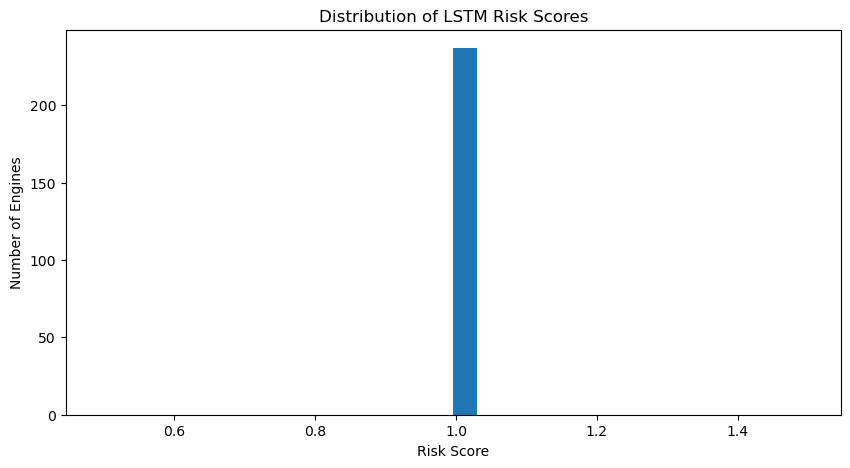

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(engine_results["risk_score_lstm"], bins=30)

plt.title("Distribution of LSTM Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Engines")

plt.show()

## Fleet Risk Visualization

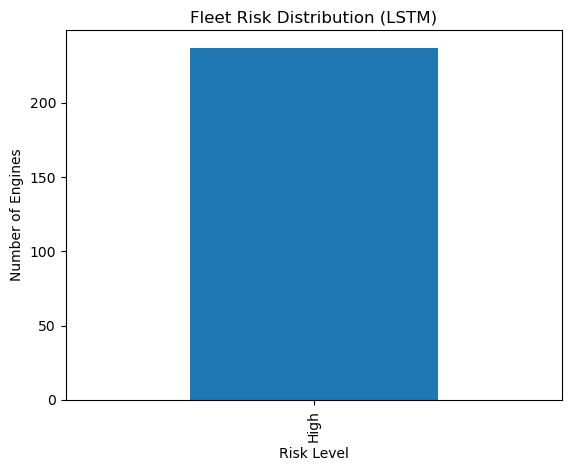

In [12]:
import matplotlib.pyplot as plt

engine_results["risk_level_lstm"].value_counts().plot(
    kind="bar",
    title="Fleet Risk Distribution (LSTM)"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Engines")
plt.show()

## Fleet Risk Score Comparison (LSTM vs GRU)

To better understand the predictive behavior of both models, we compare the
distribution of risk scores produced by the **LSTM** and **GRU** models.

Visualizing both distributions together helps identify:

- Differences in model sensitivity to degradation patterns
- Whether one model predicts higher operational risk more frequently
- Overall consistency between the two predictive models

Each histogram represents the **number of engines** falling into different
risk score ranges.

Risk score interpretation:

- **Score close to 1 → High operational risk**
- **Score close to 0 → Low operational risk**

This comparison provides insight into how the two models prioritize
engines for inspection or preventive maintenance.

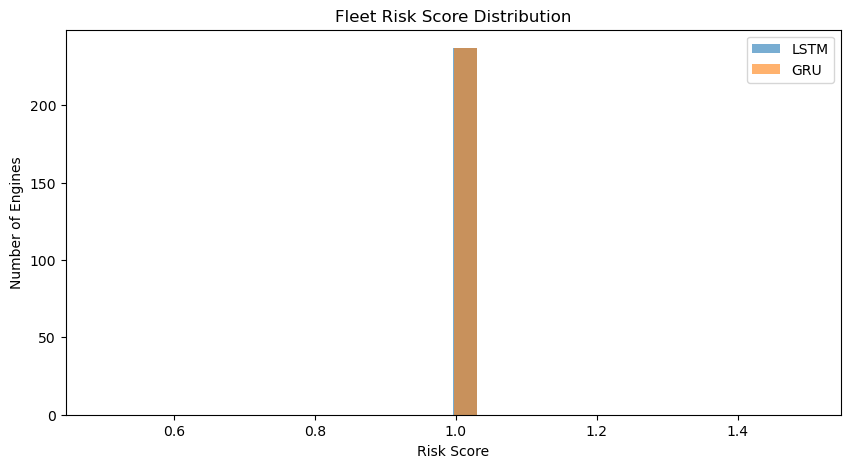

In [14]:
plt.figure(figsize=(10,5))

plt.hist(engine_results["risk_score_lstm"], bins=30, alpha=0.6, label="LSTM")
plt.hist(engine_results["risk_score_gru"], bins=30, alpha=0.6, label="GRU")

plt.title("Fleet Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Engines")

plt.legend()

plt.show()

## Save Outputs

We save outputs for dashboarding, reporting, and maintenance prioritization.

In [15]:
engine_results.to_csv(OUTPUT_DIR / "risk_scoring_results.csv", index=False)

fleet_ranking_lstm.to_csv(OUTPUT_DIR / "fleet_ranking_lstm.csv", index=False)

fleet_ranking_gru.to_csv(OUTPUT_DIR / "fleet_ranking_gru.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: C:\Users\Kal\aircraft-engine-safety-risk-prediction\outputs


# Summary

This notebook converted model predictions into operational
fleet risk insights for predictive aircraft maintenance.

Completed tasks:

✔ Generated engine-level RUL predictions using LSTM and GRU models  
✔ Converted predicted RUL into normalized risk scores  
✔ Assigned operational risk levels (High / Medium / Low)  
✔ Generated early warning alerts for critical engines  
✔ Ranked engines by fleet risk priority  
✔ Analyzed and visualized fleet risk distribution  

These outputs support maintenance planning, early failure
detection, and improved operational safety.el governance.